In [11]:
# ============================================================
# CELL 1: Install Libraries (Updated)
# ============================================================

!pip install langchain langchain-community langchain-core --quiet
!pip install langchain-text-splitters langchain-groq --quiet
!pip install langgraph faiss-cpu sentence-transformers --quiet
!pip install streamlit --quiet

print("All libraries installed!")

All libraries installed!


In [12]:
# ============================================================
# CELL 2: Import All Libraries (Updated for LangChain v0.3+)
# ============================================================

import os
import time
import warnings
warnings.filterwarnings('ignore')

# LangChain updated imports
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# Vector store & embeddings
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

# LLM
from langchain_groq import ChatGroq

import numpy as np
import matplotlib.pyplot as plt

print("All imports successful!")

All imports successful!


In [13]:
# ============================================================
# CELL 3: Setup Groq API
# ============================================================

GROQ_API_KEY = ""  # ← paste your key
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

# Initialize LLM
llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model_name="llama-3.3-70b-versatile",
    temperature=0.3,      # lower = more factual answers
    max_tokens=1024
)

print("LLM initialized!")
print(f"Model: llama-3.3-70b-versatile via Groq")

LLM initialized!
Model: llama-3.3-70b-versatile via Groq


In [14]:
# ============================================================
# CELL 4: Create Knowledge Base (Custom Corpus)
# ============================================================
# This is your document collection the chatbot will answer from
# In production: load PDFs, Wikipedia pages, company docs etc.
# Here we create a rich knowledge base about AI/ML topics

documents_text = {

"ai_history": """
Artificial Intelligence History and Overview

Artificial Intelligence (AI) was formally founded as a field in 1956 at the
Dartmouth Conference, organized by John McCarthy, Marvin Minsky, Nathaniel
Rochester, and Claude Shannon. John McCarthy coined the term 'artificial
intelligence' at this conference.

The history of AI can be divided into several periods:

The Early Years (1950s-1960s): Alan Turing proposed the Turing Test in 1950
as a measure of machine intelligence. Early programs like Logic Theorist and
General Problem Solver were developed. Researchers were optimistic about
achieving human-level AI within decades.

The First AI Winter (1974-1980): Progress slowed dramatically due to
computational limitations and overpromising. Funding was cut significantly.
The Lighthill Report in 1973 criticized AI research progress.

Expert Systems Era (1980s): Rule-based systems called expert systems became
popular in business. XCON at Digital Equipment Corporation saved millions.
Japan launched the Fifth Generation Computer project.

The Second AI Winter (1987-1993): Expert systems proved too brittle and
expensive to maintain. The market for specialized AI hardware collapsed.

Machine Learning Rise (1990s-2000s): Statistical approaches replaced
symbolic AI. Support Vector Machines and decision trees became popular.
IBM's Deep Blue defeated chess champion Garry Kasparov in 1997.

Deep Learning Revolution (2010s-present): In 2012, AlexNet won ImageNet
competition by a huge margin using deep convolutional neural networks.
GPUs enabled training of much larger models. Breakthroughs in image
recognition, speech recognition, and natural language processing followed.
""",

"machine_learning": """
Machine Learning Fundamentals

Machine Learning (ML) is a subset of AI that enables systems to learn
from data without being explicitly programmed. Instead of writing rules,
you provide examples and the algorithm learns the pattern.

Types of Machine Learning:

Supervised Learning: The model learns from labeled training data.
Examples include classification (spam detection, image recognition)
and regression (house price prediction, stock forecasting). Common
algorithms include Linear Regression, Logistic Regression, Decision
Trees, Random Forests, Support Vector Machines, and Neural Networks.

Unsupervised Learning: The model finds patterns in unlabeled data.
Examples include clustering (customer segmentation), dimensionality
reduction (PCA), and anomaly detection. Common algorithms include
K-Means, DBSCAN, and Autoencoders.

Reinforcement Learning: An agent learns by interacting with an
environment and receiving rewards or penalties. Used in game playing
(AlphaGo), robotics, and recommendation systems.

Semi-supervised Learning: Combines small amounts of labeled data
with large amounts of unlabeled data.

Key ML Concepts:
- Training set: data used to train the model
- Validation set: data used to tune hyperparameters
- Test set: data used for final evaluation
- Overfitting: model memorizes training data, fails on new data
- Underfitting: model too simple to capture patterns
- Cross-validation: robust evaluation technique
- Feature engineering: creating useful inputs from raw data
- Hyperparameter tuning: optimizing model configuration
""",

"deep_learning": """
Deep Learning and Neural Networks

Deep Learning is a subset of machine learning using neural networks
with many layers (hence 'deep'). It has revolutionized AI by achieving
human-level performance on many tasks.

Neural Network Basics:
A neural network consists of layers of interconnected nodes (neurons).
Input layer receives raw data. Hidden layers transform the data through
mathematical operations. Output layer produces the final prediction.
Each connection has a weight that is learned during training.

Key Architectures:

Convolutional Neural Networks (CNNs): Designed for image data. Use
convolutional filters to detect features like edges, textures, and
shapes. Applications: image classification, object detection, medical
imaging. Famous models: LeNet, AlexNet, VGG, ResNet, EfficientNet.

Recurrent Neural Networks (RNNs): Designed for sequential data.
Maintain a hidden state that captures information from previous steps.
Applications: text generation, speech recognition, time series.
LSTM and GRU variants solve the vanishing gradient problem.

Transformers: Attention-based architecture introduced in 2017 paper
'Attention is All You Need'. Parallelizable unlike RNNs. Became
dominant architecture for NLP. BERT, GPT, T5 are transformer models.
Self-attention allows each position to attend to all other positions.

Training Deep Networks:
Backpropagation algorithm computes gradients. Stochastic Gradient
Descent and variants (Adam, RMSprop) update weights. Batch normalization
stabilizes training. Dropout prevents overfitting. Learning rate
scheduling improves convergence.
""",

"transformers_llm": """
Transformers and Large Language Models

The Transformer architecture was introduced in the 2017 paper
'Attention is All You Need' by Vaswani et al. at Google. It
revolutionized natural language processing and became the foundation
for all modern large language models.

Key Components of Transformers:
Self-Attention Mechanism: Allows each token to attend to all other
tokens in the sequence. Captures long-range dependencies better than
RNNs. Multi-head attention runs attention multiple times in parallel.

Positional Encoding: Since transformers process all tokens in parallel
(unlike sequential RNNs), positional encodings add information about
token position in the sequence.

Feed-Forward Networks: Each transformer layer has a feed-forward
network applied to each position independently.

Notable Transformer Models:

BERT (2018, Google): Bidirectional Encoder Representations from
Transformers. Pre-trained on masked language modeling and next sentence
prediction. Excellent for classification, NER, question answering.
bert-base has 110M parameters, bert-large has 340M parameters.

GPT Series (OpenAI): Generative Pretrained Transformers. GPT-3 has
175 billion parameters. GPT-4 is multimodal. Used for text generation,
coding, reasoning, conversation.

LLaMA (Meta): Open-source large language models. LLaMA 3 available
in 8B and 70B parameter versions. Powers many open-source AI apps.

Fine-tuning vs Prompting:
Fine-tuning updates model weights on task-specific data. Requires
GPU and training time but gives best performance. Prompt engineering
shapes model behavior without changing weights. Fast and cheap.
Few-shot prompting provides examples in the context window.
RAG retrieves relevant documents to augment the prompt.
""",

"python_ml_tools": """
Python Tools for Machine Learning

Python is the dominant programming language for machine learning and
AI due to its rich ecosystem of libraries and ease of use.

Core Data Science Libraries:

NumPy: Fundamental package for numerical computing. Provides N-dimensional
arrays, mathematical functions, linear algebra operations. The foundation
for most other ML libraries. Essential operations: array creation,
indexing, broadcasting, vectorized operations.

Pandas: Data manipulation and analysis library. DataFrame structure for
tabular data. Operations: loading CSV/Excel, filtering, groupby, merging,
handling missing values, feature engineering. Essential for data preprocessing.

Matplotlib and Seaborn: Visualization libraries. Matplotlib is low-level
but flexible. Seaborn provides beautiful statistical visualizations.
Common plots: scatter, histogram, box plot, heatmap, bar chart.

Machine Learning Libraries:

Scikit-learn: Most popular traditional ML library. Provides consistent
API for all algorithms. Includes preprocessing, model selection, evaluation
metrics, and pipeline construction. Supports classification, regression,
clustering, dimensionality reduction.

PyTorch: Deep learning framework developed by Meta. Dynamic computation
graph (eager execution). Preferred by researchers. Used for CNNs, RNNs,
Transformers. torchvision for computer vision, torchaudio for audio.

TensorFlow and Keras: Deep learning framework by Google. Keras provides
high-level API. TensorFlow Serving for production deployment. TFLite
for mobile deployment. Strong production tooling.

Hugging Face Transformers: Library for state-of-the-art NLP models.
Provides thousands of pretrained models. Simple API for fine-tuning.
Datasets library for easy data loading. Hub for sharing models.

Specialized Tools:
LangChain: Framework for LLM applications, RAG systems, agents.
Gradio and Streamlit: Web UI frameworks for ML demos.
MLflow and Weights & Biases: Experiment tracking and model management.
FAISS: Efficient similarity search for vector embeddings.
""",

}

# Create LangChain Document objects
docs = []
for topic, content in documents_text.items():
    doc = Document(
        page_content=content,
        metadata={"topic": topic, "source": f"{topic}.txt"}
    )
    docs.append(doc)

print(f"Knowledge base created!")
print(f"Total documents: {len(docs)}")
for doc in docs:
    print(f"  {doc.metadata['topic']:<25} "
          f"({len(doc.page_content)} chars)")

Knowledge base created!
Total documents: 5
  ai_history                (1682 chars)
  machine_learning          (1563 chars)
  deep_learning             (1598 chars)
  transformers_llm          (1741 chars)
  python_ml_tools           (2055 chars)


In [15]:
# ============================================================
# CELL 5: Split Documents into Chunks
# ============================================================
# Large documents need to be split into smaller chunks
# because:
# 1. LLMs have context window limits
# 2. Smaller chunks = more precise retrieval
# 3. We want to retrieve only the relevant paragraph

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,       # each chunk max 500 characters
    chunk_overlap=50,     # 50 char overlap between chunks
                          # overlap ensures no info lost at boundaries
    length_function=len,
    separators=["\n\n", "\n", " ", ""]
    # tries to split on paragraphs first, then lines, then spaces
)

chunks = text_splitter.split_documents(docs)

print(f"Documents split into chunks!")
print(f"Original documents: {len(docs)}")
print(f"Total chunks:       {len(chunks)}")
print(f"Avg chunk size:     "
      f"{np.mean([len(c.page_content) for c in chunks]):.0f} chars")

print(f"\nSample chunk:")
print(f"  Topic:   {chunks[5].metadata['topic']}")
print(f"  Content: {chunks[5].page_content[:200]}...")

Documents split into chunks!
Original documents: 5
Total chunks:       25
Avg chunk size:     347 chars

Sample chunk:
  Topic:   machine_learning
  Content: Types of Machine Learning:

Supervised Learning: The model learns from labeled training data.
Examples include classification (spam detection, image recognition)
and regression (house price prediction...


In [16]:
# ============================================================
# CELL 6: Create Embeddings and Build FAISS Vector Store
# ============================================================
# Embeddings convert text to vectors (numbers)
# FAISS stores these vectors and finds similar ones fast
#
# We use a FREE sentence-transformers model — no API key needed!
# all-MiniLM-L6-v2 = small, fast, good quality embeddings

print("Loading embedding model...")
print("(Downloads ~80MB on first run)\n")

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={'device': 'cpu'},  # embeddings on CPU is fine
    encode_kwargs={'normalize_embeddings': True}
)

print("Creating vector store from document chunks...")
print("(Converting all chunks to embeddings)\n")

vectorstore = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

print(f"✅ Vector store created!")
print(f"Total vectors stored: {vectorstore.index.ntotal}")

# Test retrieval
print(f"\nTesting retrieval with sample query:")
query = "What is BERT and how does it work?"
similar_docs = vectorstore.similarity_search(query, k=3)
print(f"Query: '{query}'")
print(f"Top 3 relevant chunks found:")
for i, doc in enumerate(similar_docs):
    print(f"\n  Chunk {i+1} (topic: {doc.metadata['topic']}):")
    print(f"  {doc.page_content[:150]}...")

Loading embedding model...
(Downloads ~80MB on first run)



BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Creating vector store from document chunks...
(Converting all chunks to embeddings)

✅ Vector store created!
Total vectors stored: 25

Testing retrieval with sample query:
Query: 'What is BERT and how does it work?'
Top 3 relevant chunks found:

  Chunk 1 (topic: transformers_llm):
  Feed-Forward Networks: Each transformer layer has a feed-forward
network applied to each position independently.

Notable Transformer Models:

BERT (2...

  Chunk 2 (topic: deep_learning):
  Transformers: Attention-based architecture introduced in 2017 paper
'Attention is All You Need'. Parallelizable unlike RNNs. Became
dominant architect...

  Chunk 3 (topic: transformers_llm):
  Transformers and Large Language Models

The Transformer architecture was introduced in the 2017 paper
'Attention is All You Need' by Vaswani et al. at...


In [17]:
# ============================================================
# CELL 7: Build RAG Chain with Chat History (Modern LangChain)
# ============================================================
# Using the modern LCEL (LangChain Expression Language) approach
# instead of deprecated ConversationalRetrievalChain

# Retriever
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

# Chat history stored as simple list (replaces ConversationBufferMemory)
chat_history = []

# Prompt template — modern ChatPromptTemplate style
QA_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """You are a helpful AI assistant with expertise
in artificial intelligence and machine learning.

Use the following retrieved context to answer the question.
If the answer is not in the context, say you don't have
specific information about that, then answer from general
knowledge if possible.

Retrieved Context:
{context}"""),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{question}"),
])


def format_docs(docs):
    """Format retrieved documents into a single string."""
    return "\n\n".join(doc.page_content for doc in docs)


def get_relevant_docs(question):
    """Retrieve relevant chunks for a question."""
    return retriever.invoke(question)


# Build the RAG chain using LCEL pipe syntax
# question → retriever → format → prompt → llm → parse
rag_chain = (
    RunnablePassthrough.assign(
        context=lambda x: format_docs(
            get_relevant_docs(x["question"])
        )
    )
    | QA_PROMPT
    | llm
    | StrOutputParser()
)

print("✅ RAG chain built!")
print("\nChain components:")
print("  Retriever  → FAISS similarity search (top 3 chunks)")
print("  Memory     → chat_history list (manual management)")
print("  LLM        → LLaMA 3.3 70B via Groq")
print("  Chain type → LCEL (modern LangChain)")

✅ RAG chain built!

Chain components:
  Retriever  → FAISS similarity search (top 3 chunks)
  Memory     → chat_history list (manual management)
  LLM        → LLaMA 3.3 70B via Groq
  Chain type → LCEL (modern LangChain)


In [18]:
# ============================================================
# CELL 8: Test the RAG Chain
# ============================================================

def ask_rag(question, show_sources=True):
    """
    Ask the RAG chatbot a question with conversation memory.
    """
    global chat_history

    print(f"\n{'='*60}")
    print(f"👤 Question: {question}")
    print(f"{'='*60}")

    # Get relevant source documents
    source_docs = get_relevant_docs(question)

    # Run chain with chat history
    answer = rag_chain.invoke({
        "question": question,
        "chat_history": chat_history
    })

    print(f"\n🤖 Answer:\n{answer}")

    if show_sources:
        print(f"\n📚 Sources used:")
        for i, doc in enumerate(source_docs):
            print(f"  Source {i+1}: {doc.metadata['topic']}")
            print(f"  Preview: {doc.page_content[:100]}...")

    # Update chat history
    chat_history.append(HumanMessage(content=question))
    chat_history.append(AIMessage(content=answer))

    return answer


# Test questions
test_questions = [
    "When was artificial intelligence founded and who founded it?",
    "What is the difference between supervised and unsupervised learning?",
    "How does BERT differ from GPT models?",
    "What Python libraries are used for machine learning?",
]

print("Testing RAG chain...\n")
for question in test_questions:
    ask_rag(question, show_sources=True)
    time.sleep(1)

Testing RAG chain...


👤 Question: When was artificial intelligence founded and who founded it?

🤖 Answer:
Artificial Intelligence (AI) was formally founded as a field in 1956 at the Dartmouth Conference. The conference was organized by John McCarthy, Marvin Minsky, Nathaniel Rochester, and Claude Shannon. It was John McCarthy who coined the term 'artificial intelligence' at this conference.

📚 Sources used:
  Source 1: ai_history
  Preview: Artificial Intelligence History and Overview

Artificial Intelligence (AI) was formally founded as a...
  Source 2: ai_history
  Preview: The Early Years (1950s-1960s): Alan Turing proposed the Turing Test in 1950
as a measure of machine ...
  Source 3: ai_history
  Preview: Expert Systems Era (1980s): Rule-based systems called expert systems became
popular in business. XCO...

👤 Question: What is the difference between supervised and unsupervised learning?

🤖 Answer:
The main difference between supervised and unsupervised learning is the type of d

In [19]:
# ============================================================
# CELL 9: Test Conversation Memory
# ============================================================

# Reset chat history for fresh conversation
chat_history = []

print("Testing multi-turn conversation with memory...\n")

conversation = [
    "Tell me about transformers in AI",
    "Who created this architecture?",
    "What year was it published?",
    "How is it different from RNNs?",
    "Which companies use it most?"
]

for question in conversation:
    ask_rag(question, show_sources=False)
    time.sleep(1)

Testing multi-turn conversation with memory...


👤 Question: Tell me about transformers in AI

🤖 Answer:
Transformers are a type of artificial intelligence (AI) architecture introduced in the 2017 paper "Attention is All You Need" by Vaswani et al. at Google. They revolutionized the field of natural language processing (NLP) and have since become the foundation for many modern large language models.

The key components of transformers include:

1. **Self-Attention Mechanism**: This allows each token (e.g., word or character) in a sequence to attend to all other tokens in the sequence, capturing long-range dependencies more effectively than traditional recurrent neural networks (RNNs). Multi-head attention is a variant that runs attention multiple times in parallel.
2. **Positional Encoding**: Since transformers process all tokens in parallel, positional encodings add information about the token's position in the sequence, which is essential for understanding the context and relationshi

Visualizing document embeddings in 2D...


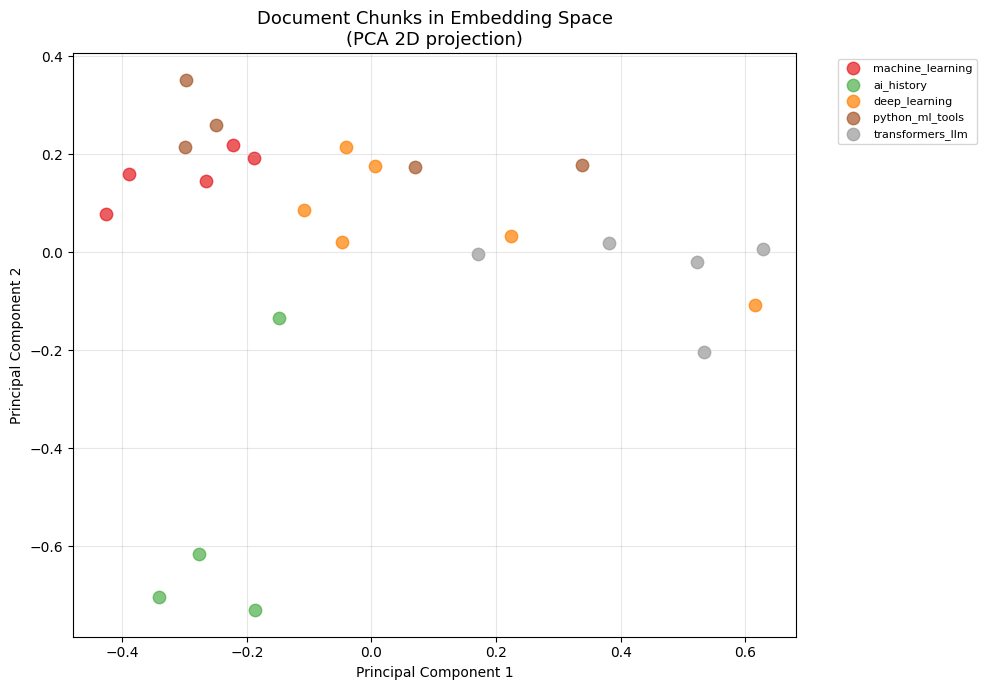

Variance explained: 27.6%


In [20]:
# ============================================================
# CELL 10: Visualize Document Embeddings
# ============================================================
# Show how chunks cluster in vector space by topic
# Use PCA to reduce from 384 dimensions to 2D for plotting

from sklearn.decomposition import PCA

print("Visualizing document embeddings in 2D...")

# Get embeddings for all chunks
chunk_texts  = [c.page_content for c in chunks]
chunk_topics = [c.metadata['topic'] for c in chunks]

# Generate embeddings
chunk_embeddings = embeddings.embed_documents(chunk_texts)
chunk_embeddings = np.array(chunk_embeddings)

# Reduce to 2D using PCA
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(chunk_embeddings)

# Plot
plt.figure(figsize=(10, 7))

unique_topics = list(set(chunk_topics))
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_topics)))
color_map = dict(zip(unique_topics, colors))

for topic in unique_topics:
    mask = [t == topic for t in chunk_topics]
    pts  = embeddings_2d[mask]
    plt.scatter(pts[:, 0], pts[:, 1],
                label=topic,
                color=color_map[topic],
                alpha=0.7, s=80)

plt.title('Document Chunks in Embedding Space\n'
          '(PCA 2D projection)', fontsize=13)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
           fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# WHAT TO LOOK FOR:
# Chunks from same topic should cluster together
# Different topics should be separated in space

In [21]:
# ============================================================
# CELL 11: Save Vector Store to Disk
# ============================================================
# Save so we don't need to recompute embeddings every time

VECTORSTORE_PATH = "./vectorstore"

vectorstore.save_local(VECTORSTORE_PATH)

print(f"✅ Vector store saved to {VECTORSTORE_PATH}")
print("\nSaved files:")
import os
for f in os.listdir(VECTORSTORE_PATH):
    size = os.path.getsize(
        f"{VECTORSTORE_PATH}/{f}") / 1024
    print(f"  {f:<30} {size:.1f} KB")

print("\nTo reload later:")
print("vectorstore = FAISS.load_local(")
print("    './vectorstore', embeddings,")
print("    allow_dangerous_deserialization=True)")

✅ Vector store saved to ./vectorstore

Saved files:
  index.faiss                    37.5 KB
  index.pkl                      11.5 KB

To reload later:
vectorstore = FAISS.load_local(
    './vectorstore', embeddings,
    allow_dangerous_deserialization=True)


In [22]:
# ============================================================
# CELL 12: Save Streamlit App
# ============================================================

app_code = '''
import streamlit as st
import os
import time
from langchain.memory import ConversationBufferMemory
from langchain.chains import ConversationalRetrievalChain
from langchain.prompts import PromptTemplate
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_groq import ChatGroq

# Page config
st.set_page_config(
    page_title="AI Knowledge Chatbot (RAG)",
    page_icon="🤖",
    layout="wide"
)

st.title("🤖 AI Knowledge Chatbot")
st.markdown("Powered by **RAG** (Retrieval-Augmented Generation) + LLaMA 3")
st.markdown("---")

# API Key input
groq_key = st.sidebar.text_input(
    "Groq API Key",
    type="password",
    placeholder="gsk_..."
)

# Load components
@st.cache_resource
def load_rag_chain(api_key):
    embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )
    vectorstore = FAISS.load_local(
        "./vectorstore",
        embeddings,
        allow_dangerous_deserialization=True
    )
    retriever = vectorstore.as_retriever(
        search_kwargs={"k": 3}
    )
    llm = ChatGroq(
        api_key=api_key,
        model_name="llama-3.3-70b-versatile",
        temperature=0.3,
        max_tokens=1024
    )
    memory = ConversationBufferMemory(
        memory_key="chat_history",
        return_messages=True,
        output_key="answer"
    )
    chain = ConversationalRetrievalChain.from_llm(
        llm=llm,
        retriever=retriever,
        memory=memory,
        return_source_documents=True,
    )
    return chain

# Sidebar info
with st.sidebar:
    st.markdown("### Knowledge Base Topics")
    st.markdown("""
    - AI History & Origins
    - Machine Learning Fundamentals
    - Deep Learning & Neural Networks
    - Transformers & LLMs (BERT, GPT)
    - Python ML Tools & Libraries
    """)
    st.markdown("---")
    if st.button("Clear Conversation"):
        st.session_state.messages = []
        st.rerun()

# Chat history
if "messages" not in st.session_state:
    st.session_state.messages = []

# Display chat history
for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.markdown(msg["content"])

# Chat input
if prompt := st.chat_input("Ask about AI/ML..."):
    if not groq_key:
        st.error("Please enter your Groq API key in the sidebar!")
    else:
        # Add user message
        st.session_state.messages.append(
            {"role": "user", "content": prompt}
        )
        with st.chat_message("user"):
            st.markdown(prompt)

        # Get response
        with st.chat_message("assistant"):
            with st.spinner("Searching knowledge base..."):
                chain = load_rag_chain(groq_key)
                result = chain.invoke({"question": prompt})
                answer = result["answer"]

                st.markdown(answer)

                # Show sources
                if result.get("source_documents"):
                    with st.expander("📚 Sources used"):
                        for doc in result["source_documents"]:
                            st.markdown(
                                f"**{doc.metadata['topic']}**: "
                                f"{doc.page_content[:150]}..."
                            )

        st.session_state.messages.append(
            {"role": "assistant", "content": answer}
        )
'''

with open("rag_app.py", "w") as f:
    f.write(app_code)

print("✅ Streamlit app saved as rag_app.py")

✅ Streamlit app saved as rag_app.py


In [23]:
# ============================================================
# CELL 13: Run Streamlit App via Cloudflare Tunnel
# ============================================================

!pip install streamlit pyngrok --quiet

import subprocess
import time
import re

# Start Streamlit
subprocess.Popen(
    ["streamlit", "run", "rag_app.py",
     "--server.port=8501",
     "--server.headless=true",
     "--server.enableCORS=false"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
time.sleep(5)
print("Streamlit started!")

# Cloudflare tunnel
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

tunnel = subprocess.Popen(
    ["./cloudflared", "tunnel",
     "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("Getting public URL (wait 10 seconds)...")
time.sleep(10)

for _ in range(30):
    line = tunnel.stderr.readline().decode("utf-8")
    match = re.search(
        r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com',
        line
    )
    if match:
        url = match.group(0)
        print(f"\n✅ RAG Chatbot is live at:")
        print(f"👉  {url}")
        print("\nEnter your Groq API key in the sidebar!")
        break

Streamlit started!
Getting public URL (wait 10 seconds)...

✅ RAG Chatbot is live at:
👉  https://feedback-experiences-institute-modem.trycloudflare.com

Enter your Groq API key in the sidebar!


## Task 4 — Key Insights: RAG Chatbot with LangChain

**Objective:** Build a context-aware chatbot that retrieves
information from a custom knowledge base

**Knowledge Base:** 5 AI/ML topic documents
- AI History, Machine Learning, Deep Learning,
  Transformers/LLMs, Python ML Tools

**RAG Pipeline:**
1. Documents split into 500-char chunks (50 overlap)
2. Chunks embedded using sentence-transformers/all-MiniLM-L6-v2
3. Embeddings stored in FAISS vector database
4. User question embedded → similarity search → top 3 chunks
5. Chunks + question + memory → LLM → answer

**Components Used:**
- LangChain: orchestration framework
- FAISS: vector similarity search
- HuggingFace Embeddings: free sentence embeddings
- LLaMA 3.3 70B via Groq: answer generation
- ConversationBufferMemory: chat history

**Key Findings:**
- RAG dramatically improves factual accuracy vs plain LLM
- Conversation memory enables natural multi-turn dialogue
- Similar topics cluster together in embedding space (visualized)
- Source attribution shows exactly which document chunk was used

**RAG vs Plain LLM:**
- Plain LLM: answers from training data only, may hallucinate
- RAG: answers from YOUR documents, more accurate and traceable

**Deployment:** Streamlit app with sidebar API key input,
chat interface, and source document expander